In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import sympy as sp
from scipy.integrate import solve_bvp
from scipy.integrate import trapezoid
from scipy.integrate import cumulative_trapezoid

In [55]:
#given parameters
nu_inf = 1.5e-6 #freestream kinematic viscosity - m2/s
u_inf = 30 #freestream vel - m/s
L = 1 #m
delta = 0.005 #initial boundary layer thickness - m

Ny = 150 #y partitions
y_max = 10*delta #max y 
s = 10 #stretch factor

#estimate x0 for Blasius solution:
x0 = (delta/5.0)**2*(u_inf/nu_inf) 

x_tot = 40*L #independent var length
dx = 0.01 #x step size
Nx = int(x_tot/dx) #x partitions

#eta grid
eta = np.linspace(0, 1, Ny)
d_eta = eta[1] - eta[0]

#stretched y grid
y = y_max*(np.sinh(s*eta)/np.sinh(s))

#stretched y grid derivatives (solved for at end of code symbolically)
deta_dy = np.sinh(s)/(s*y_max*np.cosh(s*eta))
d2eta_dy2 = -(np.sinh(s)**2*np.sinh(s*eta))/(s*y_max**2*np.cosh(s*eta)**3)

In [56]:
#central diff, 4th order for interior points, 2nd order for boundary-adjacent points
du_deta = np.zeros((Ny, Ny))
d2u_deta2 = np.zeros((Ny, Ny))

for i in range(1, Ny - 1):
    if i == 1 or i == Ny - 2:
        #2nd order cd, for boundary-adjacent points
        du_deta[i, i-1] = -1/(2*d_eta) 
        du_deta[i, i+1] = 1/(2*d_eta)
        
        d2u_deta2[i, i-1] = 1/d_eta**2
        d2u_deta2[i, i] = -2/d_eta**2
        d2u_deta2[i, i+1] = 1/d_eta**2
    else:
        #4th order cd, for interior points
        du_deta[i, i-2] = 1/(12*d_eta)
        du_deta[i, i-1] = -8/(12*d_eta)
        du_deta[i, i+1] = 8/(12*d_eta)
        du_deta[i, i+2] = -1/(12*d_eta)
        
        d2u_deta2[i, i-2] = -1/(12*d_eta**2)
        d2u_deta2[i, i-1] = 16/(12*d_eta**2)
        d2u_deta2[i, i] = -30/(12*d_eta**2)
        d2u_deta2[i, i+1] = 16/(12*d_eta**2)
        d2u_deta2[i, i+2] = -1/(12*d_eta**2)

In [ ]:
u = np.zeros(Ny)  #init u
v = np.zeros(Ny)  #init v

#at the initial location, assume that the velocity profile in the x direction is given by:
for i in range(Ny):
    if y[i]/delta <= 1:
        u[i] = u_inf*(y[i]/delta*(3/2-1/2*((y[i]/delta)**2))) 
    else:
        u[i] = u_inf

x_vals = [1000, 2000, 3000, 4000] #x steps ->x= 20 + n/100
u_store_numer = [u.copy()] #initialize u storing
v_store_numer = [v.copy()] #initialize v storing

for n in range(1, Nx + 1): 
    
    #diffusion convection terms
    diff_conv = np.zeros((Ny, Ny))
    for i in range(1, Ny - 1):
        j = nu_inf*deta_dy[i]**2
        k = nu_inf*d2eta_dy2[i] - v[i]*deta_dy[i]

        diff_conv[i, :] = (j*d2u_deta2[i, :] + k*du_deta[i, :])
        
    #Au=b
    A = np.diag(u) -0.5*dx*diff_conv  #C-N: step n+1
    b = (np.diag(u) + 0.5*dx*diff_conv)@u  #C-N: u*du/dx at step n

    b[0] = 0; #u=0 at wall
    b[-1] = u_inf #u=u_inf at freestream

    #top boundary 
    A[-1, :] = 0; 
    A[-1, -1] = 1; 
    #bottom boundary
    A[0, :] = 0; 
    A[0, 0] = 1;     
    
    u_new = lu_solve((lu_factor(A)), b) #
    u_new[0] = 0 #enforce BC
    u_new[-1] = u_inf #enforce BC
    
    # Update v
    du_dx = (u_new - u)/dx
    v_new = np.zeros(Ny)
    for i in range(1, Ny):
        #rewrite and solve continuity
        v_new = cumulative_trapezoid(-du_dx, x=y, initial=0)
    u = u_new.copy() #store u for next iter
    v = v_new.copy() #store v for next iter

    if n in x_vals:
        u_store_numer.append(u.copy())
        v_store_numer.append(v.copy())

In [ ]:
#blasius solution for comparison
func = lambda x, y: [y[1], y[2], -0.5*y[0]*y[2]] #f''' = -0.5*f*f''
bcs = lambda ya, yb: [ya[0], ya[1], yb[1] - 1] #f(0)=0, f'(0)=0, f'(inf)=1

eta_span = np.linspace(0, 10, 100) #init range for eta
blasius_guess = np.zeros((3, eta_span.size)) #initial guess for blasius


blasius_eqn = solve_bvp(func, bcs, eta_span, blasius_guess) #solve boundary value problem
eta_exact = blasius_eqn.x 
u_exact_norm = blasius_eqn.y[1]

eta_exact = blasius_eqn.x 
u_exact_norm = blasius_eqn.y[1]

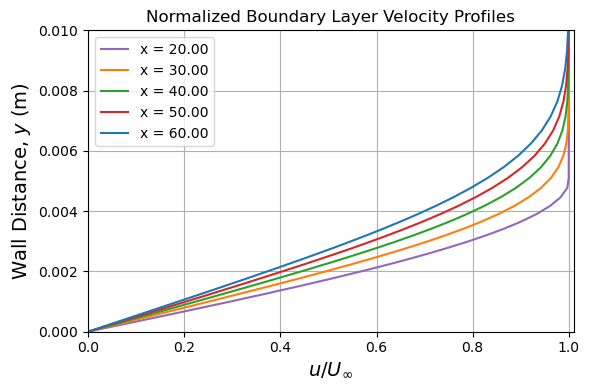

In [59]:
plt.figure(figsize=(6, 4))
colors = ['tab:purple','tab:orange','tab:green','tab:red','tab:blue']
markevery = 2

for idx, n in enumerate([0] + list(x_vals)):
    x_now = x0 + n*dx 
    plt.plot(u_store_numer[idx]/u_inf, y, '-', color=colors[idx], markersize=4, label=f'x = {x_now:.2f}')
plt.title('Normalized Boundary Layer Velocity Profiles', fontsize=12)
plt.xlabel(r'$u / U_{\infty}$', fontsize=14)
plt.ylabel(r'Wall Distance, $y$ (m)', fontsize=14)
plt.ylim(0, 0.01) 
plt.xlim(0, 1.01)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

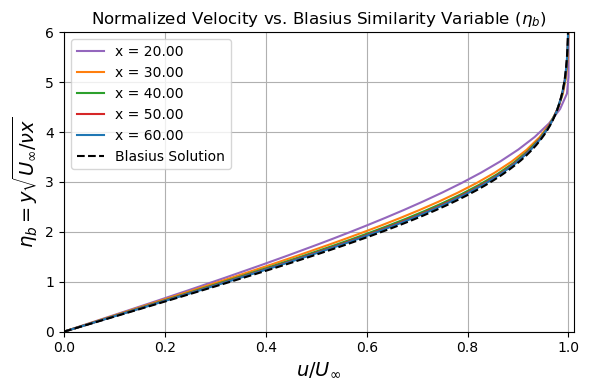

In [ ]:
plt.figure(figsize=(6, 4))
colors = ['tab:purple','tab:orange','tab:green','tab:red','tab:blue']
markevery = 2

for idx, n in enumerate([0] + list(x_vals)):
    x_now = x0 + n*dx 
    eta_now = y*np.sqrt(u_inf/(nu_inf*x_now))
    
    plt.plot(u_store_numer[idx]/u_inf, eta_now, '-', color=colors[idx], markersize=4, label=f'x = {x_now:.2f}')
    
plt.plot(u_exact_norm, eta_exact, '--', color='k',label=f'Blasius Solution')    
plt.title(r'Normalized Velocity vs. Blasius Similarity Variable ($\eta_b$)', fontsize=12)
plt.xlabel(r'$u / U_{\infty}$', fontsize=14)
plt.ylabel(r'$\eta_b = y \sqrt{U_{\infty} / \nu x}$', fontsize=14)
plt.ylim(0, 6)
plt.xlim(0, 1.01)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#calc delta*, theta, and H at each x location
print('x (m) | Delta* (m)   | Theta        |Shape Factor (H)')
#init lists
delta_stars = []
thetas = []
shape_factors = []


for idx, n in enumerate([0] + list(x_vals)):
    x_now = x0 + n*dx
    
    #disp thickness
    d_star = trapezoid(1-u_store_numer[idx]/u_inf, x=y)
    
    #momentum thickness
    theta = trapezoid(u_store_numer[idx]/u_inf*(1-u_store_numer[idx]/u_inf), x=y)
    
    #shape factor
    H = d_star/theta
    
    #store
    delta_stars.append(d_star)
    thetas.append(theta)
    shape_factors.append(H)
    
    print(f"{x_now:.2f} | {d_star:.6e} | {theta:.6e} | {H:.3f}")

#blasius dimensionless parameters for comparison
blasius_dstar = trapezoid(1 - u_exact_norm, x=eta_exact)
blasius_theta = trapezoid(u_exact_norm*(1 - u_exact_norm), x=eta_exact)
blasius_H= blasius_dstar/blasius_theta

print('blasius:')
print(f"theta: {blasius_theta:.5e}")
print(f"dstar: {blasius_dstar:.5e}")
print(f"H: {blasius_H:.5f}")

x (m) | Delta* (m)   | Theta        |Shape Factor (H)
20.00 | 1.876440e-03 | 6.969834e-04 | 2.692
30.00 | 2.212921e-03 | 8.326163e-04 | 2.658
40.00 | 2.502542e-03 | 9.517238e-04 | 2.629
50.00 | 2.769737e-03 | 1.059010e-03 | 2.615
60.00 | 3.017512e-03 | 1.157123e-03 | 2.608
blasius:
theta: 6.63851e-01
dstar: 1.72112e+00
H: 2.59262


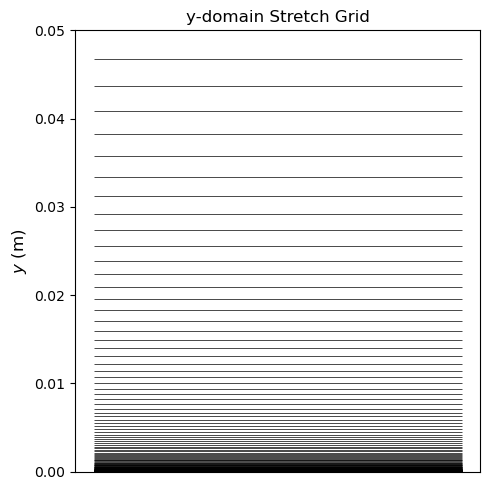

In [62]:
plt.figure(figsize=(5,5))

plt.hlines(y, xmin=0, xmax=1, colors='black', linewidth=0.5)

plt.title('y-domain Stretch Grid')
plt.ylabel(r'$y$ (m)', fontsize=12)
plt.xticks([]) #hide ticks
plt.ylim(0, y_max)

plt.tight_layout()
plt.show()

### Find $\eta$ wrt. y derivatives using symbolic solver:

In [ ]:
eta, s, y_max = sp.symbols('eta s y_max')

y = y_max*sp.sinh(s*eta) / sp.sinh(s)
dy_deta = sp.diff(y, eta)
d_eta=sp.simplify(dy_deta)
deta_dy = sp.simplify(1 / dy_deta)
d2u_deta2_eta = sp.simplify(deta_dy*sp.diff(deta_dy, eta))
print(f"{sp.latex(deta_dy)}\n")
print(f"{sp.latex(d2u_deta2_eta)}")

$$
\frac{\partial\eta}{\partial y} =\frac{\sinh{\left(s \right)}}{s y_{max} \cosh{\left(\eta s \right)}}
$$

$$
\frac{\partial^2\eta}{\partial y^2}=- \frac{\sinh^{2}{\left(s \right)} \sinh{\left(\eta s \right)}}{s y_{max}^{2} \cosh^{3}{\left(\eta s \right)}}
$$